# CIFAR-100 Classification

In [3]:
# 1. Setup
import os, sys

REPO_URL = "https://github.com/NatanSisoev/CIFAR-100-Classification.git"
REPO_DIR = "/content/CIFAR-100-Classification"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

!pip install -q loguru

Already up to date.


In [5]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 3. Imports
from configs import REMOTE_BASE_DIR, NUM_EPOCHS
from data import get_cifar100_loaders
from models import SmallResNet, get_device, plot_history, train
from models import 
from loguru import logger

ImportError: cannot import name 'train' from 'training' (unknown location)

In [ ]:
# 4. Device & data
device = get_device()
train_loader, test_loader = get_cifar100_loaders()

2026-04-01 20:04:06.757 | SUCCESS  | models.utils:get_device:50 - using device: cuda:0
2026-04-01 20:04:08.510 | INFO     | data.datasets:get_cifar100_loaders:19 - Succesfully loaded train loader.
2026-04-01 20:04:08.511 | INFO     | data.datasets:get_cifar100_loaders:20 - Succesfully loaded test loader.


In [ ]:
# 5. Init model
model = "smallresnet"
SAVE_PATH = REMOTE_BASE_DIR + f"{model}_best.pth"

match model:
    case "smallresnet":
        model, criterion, optimizer, scheduler = SmallResNet.init(device)
        # state = SmallResNet.restore(device, save_path=SAVE_PATH)
    case _:
        logger.error(f"No model {model} found!")

2026-04-01 20:09:54.288 | INFO     | models.base:init:26 - Initiated SmallResNet with 106,988 parameters


In [ ]:
# 6. Train
# Fresh start:
model, history = train(
    device=device,
    model=model,
    dataloader_train=train_loader,
    dataloader_test=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=2,
    save_path=SAVE_PATH,
)

# Resume (uncomment and replace the block above):
# model, history = train(
#     device=device,
#     dataloader_train=train_loader,
#     dataloader_test=test_loader,
#     num_epochs=NUM_EPOCHS,
#     **state,
# )

2026-04-01 20:06:14.839 | INFO     | training.train01:train:30 - Training started — 106,988 trainable parameters
2026-04-01 20:07:13.531 | INFO     | training.train01:train:81 - Epoch   1/2 | train | loss: 3.8912 | acc: 11.95%
2026-04-01 20:07:16.199 | INFO     | training.train01:train:81 - Epoch   1/2 | test  | loss: 3.7305 | acc: 14.92%
2026-04-01 20:07:16.225 | INFO     | training.train01:train:100 -  ★ New best: 14.92% — saved to '/content/drive/MyDrive/XNAP/smallresnet_best.pth'
2026-04-01 20:08:14.229 | INFO     | training.train01:train:81 - Epoch   2/2 | train | loss: 3.6979 | acc: 15.96%
2026-04-01 20:08:16.720 | INFO     | training.train01:train:81 - Epoch   2/2 | test  | loss: 3.4348 | acc: 21.72%
2026-04-01 20:08:16.744 | INFO     | training.train01:train:100 -  ★ New best: 21.72% — saved to '/content/drive/MyDrive/XNAP/smallresnet_best.pth'
2026-04-01 20:08:16.745 | INFO     | training.train01:train:107 - Training finished in 2.0 min | Best test acc: 21.72%


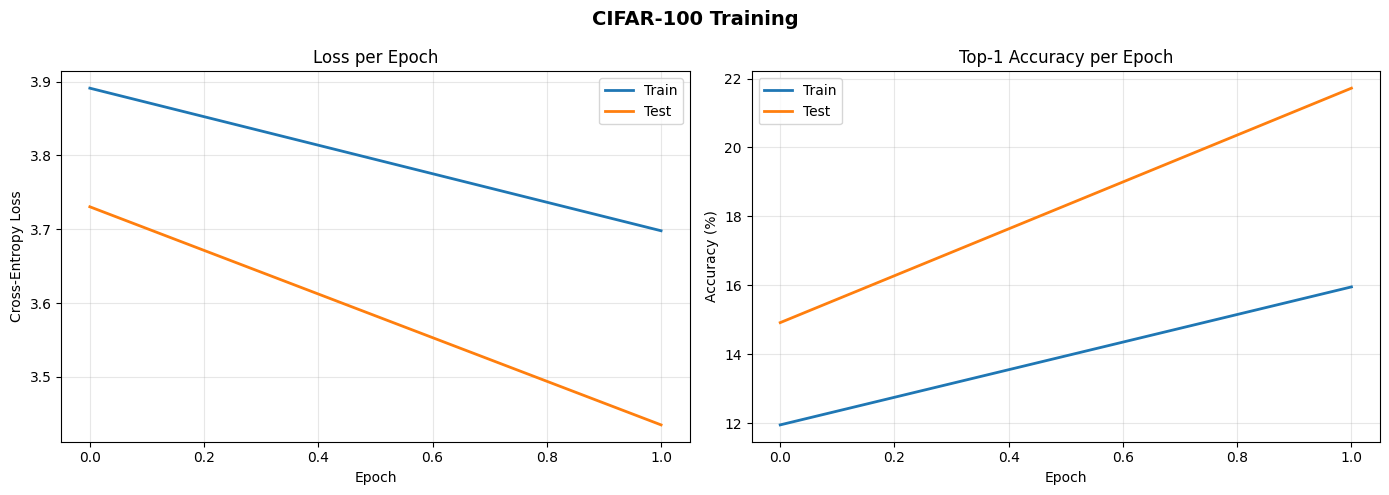

2026-04-01 20:13:21.616 | INFO     | models.utils:plot_history:40 - Training plot saved to '/content/drive/MyDrive/XNAP/history.png'


In [ ]:
# 7. Results
plot_history(history, save_path=REMOTE_BASE_DIR + "history.png")